# Data retrieval

This model is for detecting spam in emails. The dataset came from a personal task I was once given, which I decided to repurpose for this exploration. It only has two columns — category and message — and was much harder to clean compared to the other problems I worked on.  

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'spam.csv')
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


# Data cleaning

### Missing values 

In [5]:
df.isna().sum()

Category    0
Message     0
dtype: int64

### Duplicates

In [6]:
df.duplicated().sum()

np.int64(415)

In [7]:
df.drop_duplicates(inplace=True)

# Data preprocessing

### Turning Target to Numerical

The target is categorical so we can simply use label encoding to simplify and turn it to numerical form

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()
le.fit(df['Category'])

LabelEncoder()

In [10]:
df['Category'] = le.transform(df['Category'])

In [11]:
# 0 - ham and 1 - spam
df

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


### Turning msg to numerical

##### TF-IDF Vectorizer  

TF-IDF Vectorizer is part of Scikit-learn’s **feature extraction** module. It converts text into numbers by giving each word a score based on how important it is in the text. This allows the model to understand the text and make predictions.  


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)

In [14]:
X = feature_extraction.fit_transform(df['Message'])

In [15]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 39457 stored elements and shape (5157, 8440)>
  Coords	Values
  (0, 4244)	0.3499196296117096
  (0, 5775)	0.27302520999127156
  (0, 2278)	0.2702988935611362
  (0, 1281)	0.26535295747051524
  (0, 1715)	0.2951389397771093
  (0, 3551)	0.1953324619101405
  (0, 8281)	0.24707196580179255
  (0, 4370)	0.2951389397771093
  (0, 1713)	0.3338973049532707
  (0, 2003)	0.2951389397771093
  (0, 3511)	0.16364063560486042
  (0, 1061)	0.3499196296117096
  (0, 8079)	0.19572961012524212
  (1, 5373)	0.27641681599588036
  (1, 4406)	0.40693812451964195
  (1, 4212)	0.5234057786973465
  (1, 8187)	0.43046670700566175
  (1, 5399)	0.5465710490257072
  (2, 3276)	0.11510534808187987
  (2, 2885)	0.35771414622329567
  (2, 8239)	0.19624084819531654
  (2, 2119)	0.193659496325995
  (2, 8199)	0.1505669327735048
  (2, 3014)	0.47966074845722484
  (2, 2337)	0.20228440014847157
  :	:
  (5152, 2777)	0.23693240035002205
  (5152, 307)	0.24171764568758766
  (5152, 707)	

# Data splitting

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
# X already defined in preprocessing step
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(4125, 8440) (4125,) (1032, 8440) (1032,)


### Class imbalance 

The dataset was highly imbalanced (87:12). I applied the **SMOTE technique** to increase the minority class. This improved the performance metrics, and the ratio shifted to **52:47**, giving a more balanced dataset.  

In [19]:
y.value_counts()

Category
0    4516
1     641
Name: count, dtype: int64

In [20]:
y.value_counts(normalize=True)

Category
0    0.875703
1    0.124297
Name: proportion, dtype: float64

In [21]:
from imblearn.over_sampling import SMOTE

In [22]:
smote = SMOTE(sampling_strategy=0.9)

In [23]:
X_res, y_res = smote.fit_resample(X_train, y_train)

In [24]:
y_res.value_counts(normalize=True)

Category
0    0.526377
1    0.473623
Name: proportion, dtype: float64

# Model building

In [25]:
from sklearn import tree

In [26]:
dt = tree.DecisionTreeClassifier()
dt.fit(X_res, y_res)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Evaluation

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [28]:
y_pred = dt.predict(X_test)

In [29]:
acc = dt.score(X_test, y_test)
pre = precision_score(y_test, y_pred)
re = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

In [30]:
print(f"Accuracy Score       : {acc:.4f}")
print(f"Precision Score      : {pre:.4f}")
print(f"Recall Score         : {re:.4f}")
print(f"F1 Score             : {f1:.4f}")
print("\nClassification Report:\n")
print(cr)

Accuracy Score       : 0.9477
Precision Score      : 0.7803
Recall Score         : 0.8047
F1 Score             : 0.7923

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       904
           1       0.78      0.80      0.79       128

    accuracy                           0.95      1032
   macro avg       0.88      0.89      0.88      1032
weighted avg       0.95      0.95      0.95      1032



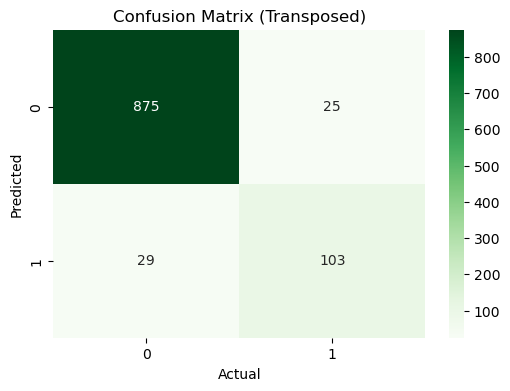

In [32]:
cmx = confusion_matrix(y_test, y_pred)
cmx = cmx.T
plt.figure(figsize=(6,4))
sns.heatmap(cmx, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix (Transposed)")
plt.show()